In [1]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
import choclo
from numpy.linalg import inv
import spherical as sph

In [2]:
TESLA_TO_NANOTESLA = 1e9

ellipsoid = bl.WGS84

coordinates = vd.grid_coordinates(
    region=(-3, 4, -2, 3),
   shape=(20,20),
    extra_coords=ellipsoid.mean_radius,
)

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

magnetic_moments = (
    np.full((1, 1), 0.0e9),  
    np.full((1, 1), 0.0e9),        
    np.full((1, 1), 1.0e13)       
)

dipoles = vd.scatter_points(
    region=(-1, 1,-1, 1),
    size= 1,
    extra_coords=ellipsoid.mean_radius-4e4,
    random_state=0
)

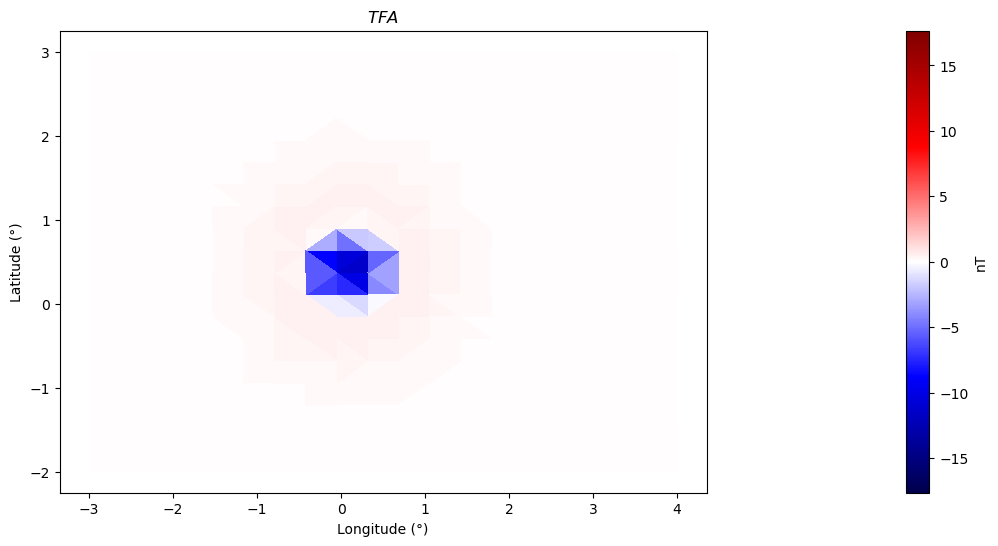

In [3]:
b_long, b_colat, b_radius = sph.foward_modeling_spherical(coordinates, dipoles, magnetic_moments)

observed_data = hm.total_field_anomaly((b_long, -b_colat, b_radius), inclination=90, declination=90)

scale = vd.maxabs(observed_data)

plt.figure(figsize=(15, 6))
plt.tripcolor(longitude, sph_latitude, observed_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()


In [4]:
# def jacobian(coordinates, dipoles, magnetic_moments, I_F, D_F):
#     """
#     """

#     dipoles = tuple(d.ravel() for d in dipoles)
#     magnetic_moments = tuple(m.ravel() for m in magnetic_moments)

#     n = len(coordinates[0])
#     m = len(dipoles[0])
#     A = np.empty((n, m))


#     for j in range(m):
#         dipole = (dipoles[0][j], dipoles[1][j], dipoles[2][j])
#         moment = (magnetic_moments[0][j], magnetic_moments[1][j], magnetic_moments[2][j])
#         b_latitude, b_colatitude, b_radius = sph.foward_modeling_spherical(coordinates, dipole, moment)

#         A[:, j] = TESLA_TO_NANOTESLA * hm.total_field_anomaly((b_latitude, -b_colatitude, b_radius),I_F, D_F)

#     return A 

In [5]:
# def jacobian(coordinates, dipoles, magnetic_moments, I_F, D_F):
#     """
#     """

#     coordinates = tuple(c.ravel() for c in coordinates)
#     dipoles = tuple(d.ravel() for d in dipoles)
#     magnetic_moments = tuple(m.ravel() for m in magnetic_moments)

#     n = (coordinates[0].size)
#     m = (dipoles[0].size)
#     A = np.empty((n, m))
   

#     for j in range(m):
#         dipole = (dipoles[0][j], dipoles[1][j], dipoles[2][j])
#         coordinate = (coordinates[0][j], coordinates[1][j], coordinates[2][j])
#         magnetic_moment = (magnetic_moments[0][j], magnetic_moments[1][j], magnetic_moments[2][j])
#         b_latitude[j], b_colatitude[j], b_radius[j] = sph.foward_modeling_spherical(coordinate, dipole, magnetic_moment)
#         A[:, j] = hm.total_field_anomaly((b_latitude, -b_colatitude, b_radius),I_F, D_F)

#     return A

In [6]:
def jacobian(coordinates, dipoles, magnetic_moments, I_F, D_F):

    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(d.ravel() for d in dipoles)
    magnetic_moments = tuple(m.ravel() for m in magnetic_moments)

    n = len(coordinates[0])  
    m = len(dipoles[0])      

    A = np.empty((n, m))


    for i in range(n):
        coordinate = (coordinates[0][i], coordinates[1][i], coordinates[2][i])
        for j in range(m):
            dipole = (dipoles[0][j], dipoles[1][j], dipoles[2][j])
            moment = (magnetic_moments[0][j], magnetic_moments[1][j], magnetic_moments[2][j])

            b_latitude, b_colatitude, b_radius = sph.foward_modeling_spherical(
                coordinate, dipole, moment
            )

            A[i, j] = TESLA_TO_NANOTESLA * hm.total_field_anomaly(
                (b_latitude, -b_colatitude, b_radius), I_F, D_F
            )

    return A


In [7]:
estimated_source_coord =  vd.grid_coordinates(
    region=(-3, 4, -2, 3),
    shape=(20, 20),
    extra_coords=ellipsoid.mean_radius - 4.5e4
)


magnetic_moments_eqs = (
    np.full((20, 20), 1.0), 
    np.full((20, 20), 1.0),     
    np.full((20, 20), 1.0)        
)

A = jacobian(
    coordinates=coordinates,
    dipoles=estimated_source_coord,
    magnetic_moments=magnetic_moments_eqs,
    I_F=90,
    D_F=90)

/tmp/ipykernel_798135/174264640.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[i, j] = TESLA_TO_NANOTESLA * hm.total_field_anomaly(


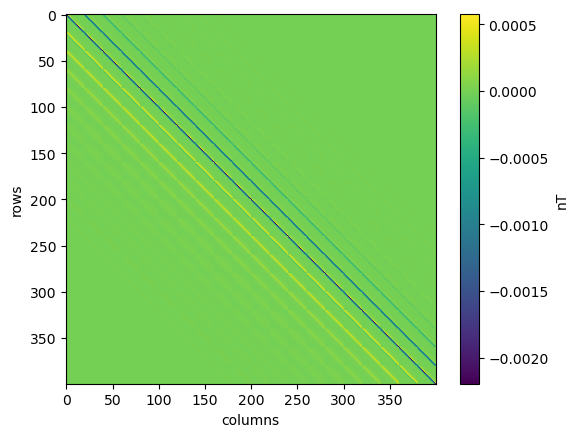

In [8]:
plt.figure()
plt.imshow(A)
plt.colorbar(label="nT")
plt.xlabel("columns")
plt.ylabel("rows")
plt.show()


In [9]:
def calculate_coefficients(observed_data, A, damping):
    
    I = np.identity(A.shape[1]) # needs to = m x m
    # np.shape(A) = A.shape
    
    system_matrix = A.T @ A + I * damping
    system_rhs_vector = A.T @ observed_data
    
    coefficients = np.linalg.solve(system_matrix, system_rhs_vector)
    
    return coefficients

In [10]:
damping = 1e-35

coefficients = calculate_coefficients(observed_data, A, damping)

print(coefficients)

[-2.41853078e+00 -1.81130683e+00 -2.57861694e+00 -3.02931400e+00
 -3.68732750e+00 -4.47112657e+00 -5.91010149e+00 -9.01362632e+00
 -1.24599374e+01 -8.19773881e+00 -4.61998326e+00 -4.00668062e+00
 -3.47717290e+00 -2.90379177e+00 -2.39513332e+00 -1.95575638e+00
 -1.58624435e+00 -1.27858456e+00 -1.01817067e+00 -8.64153510e-01
 -3.23760936e+00 -2.25410028e+00 -3.41925696e+00 -4.00651077e+00
 -4.92220992e+00 -5.62035336e+00 -5.06404919e+00 -7.31761235e-02
  8.59640479e+00  7.89016478e-01 -5.75990391e+00 -5.20097739e+00
 -4.22012882e+00 -3.44648540e+00 -2.76394372e+00 -2.20402448e+00
 -1.74847026e+00 -1.37648308e+00 -1.06051180e+00 -7.93985893e-01
 -4.36834378e+00 -3.11271400e+00 -4.76358167e+00 -5.65452455e+00
 -7.07848182e+00 -8.71479696e+00 -1.22748491e+01 -2.35904176e+01
 -4.30287306e+01 -2.49541009e+01 -8.80073883e+00 -7.08493182e+00
 -5.87926463e+00 -4.62174445e+00 -3.63537063e+00 -2.84425458e+00
 -2.21813647e+00 -1.71412097e+00 -1.28357924e+00 -9.24163205e-01
 -5.47085340e+00 -3.98177

In [11]:
grid_coord = vd.grid_coordinates(region= (-5, 5, -5, 5), shape=(100,100), extra_coords=ellipsoid.mean_radius + 200)

grid_data = np.zeros(np.shape(grid_coord[0]))


m = len(estimated_source_coord[0])

magnetic_field = sph.foward_modeling_spherical(grid_coord, estimated_source_coord, magnetic_moments_eqs)
# magnetic_field = unit_foward_modeling_spherical(grid_coord, estimated_source_coord, 1)
b_long, b_colat, b_radius = magnetic_field


for j in range(m):

    grid_data += coefficients[j] * hm.total_field_anomaly((b_long, -b_colat, b_radius),90, 90).reshape(100,100)

In [12]:
b_long_obs, b_colat_obs, b_radius_obs = sph.foward_modeling_spherical(grid_coord, dipoles, magnetic_moments)
grid_obs = hm.total_field_anomaly((b_long_obs, -b_colat_obs, b_radius_obs), 90,90).reshape(100,100)


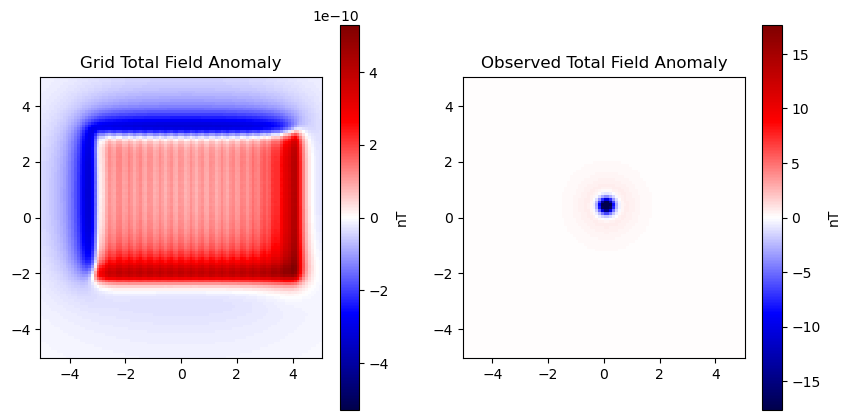

In [13]:
plt.figure(figsize=(10, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1, 2, 1)
plt.pcolormesh(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Grid Total Field Anomaly')
plt.axis("scaled")

plt.subplot(1,2,2)
scale_obs = vd.maxabs(observed_data)
plt.pcolormesh(grid_coord[0], grid_coord[1],grid_obs ,cmap="seismic", vmin=-scale_obs, vmax=scale_obs)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.axis("scaled")

plt.show()

Text(0.5, 1.0, 'Difference')

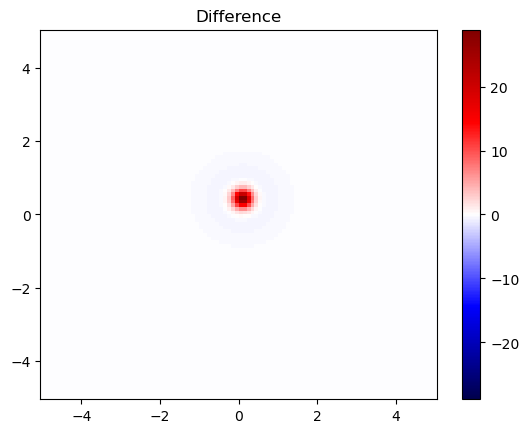

In [14]:
diff = grid_data - grid_obs
scale = vd.maxabs(diff)
plt.pcolormesh(grid_coord[0], grid_coord[1], diff,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()
plt.title('Difference')

In [15]:
mse = np.square(diff).mean() 
rmse = np.sqrt(mse)
rmse

np.float64(0.8465523805649182)

## Oi Arthur do futuro

Onde paramos? 

Você descobriu em uma conversa com o Leo que cagou no pau ao calcular a jacobiana, seu merda

Então temos que pensar em como concertar isso, pelo o que o leo dise era pra ficar mais ou menos assim: https://github.com/compgeolab/2020-aachen-inverse-problems/blob/main/gravity-inversion-solution.ipynb

no momento não sei o que fazer, mas tentei iterar em cima dos dipolos e dos momentos e nd deu certo até então, olha o código 05-eql da india